In [1]:
import sys
import os

sys.path.append(os.path.abspath("..")) 

In [2]:
sys.path.append("/home/lirn/geo_env")

In [3]:
os.getcwd()

'/home/lirn/geo_env/src/output'

In [4]:
from src.config import Config
from src.extract import data_loader

/home/lirn/geo_env/src/extract/data_loader.py:68: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_beginning'] = pd.to_datetime(df['date_beginning'])


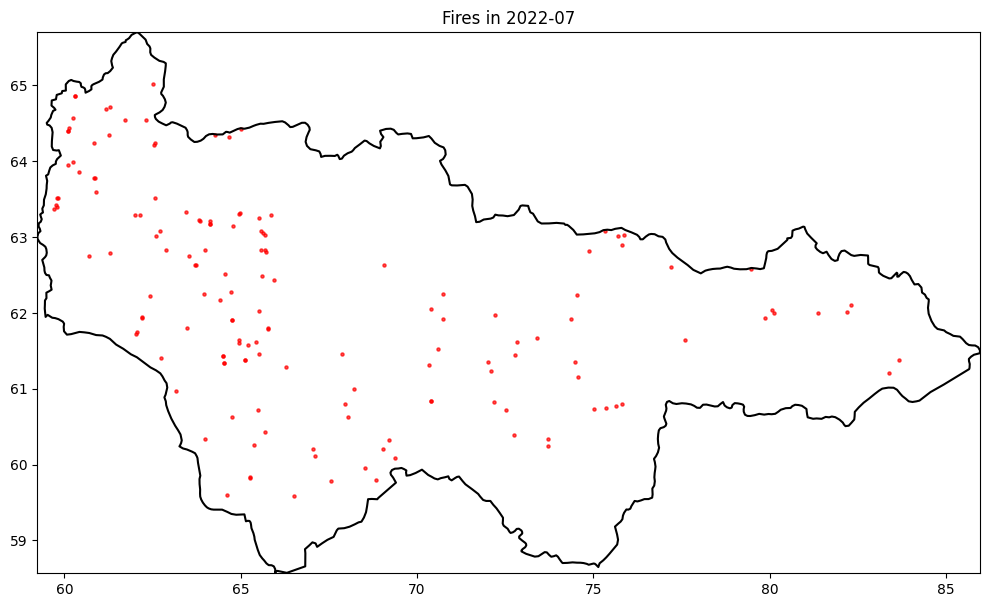

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path 
import geodatasets

def plot_fires_by_month(gdf, year, month, geojson_path):
    mask = (gdf['acq_date'].dt.year == year) & (gdf['acq_date'].dt.month == month)
    fires_subset = gdf[mask].copy()
    
    if fires_subset.empty:
        print(f"No fires found for {year}-{month:02d}")
        return
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    region = gpd.read_file(geojson_path)

    if region.crs != gdf.crs:
        region = region.to_crs(gdf.crs)

    region.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)

    fires_subset.plot(ax=ax, markersize=5, color='red', alpha=0.7)

    minx, miny, maxx, maxy = region.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(f'Fires in {year}-{month:02d}')
    plt.tight_layout()
    plt.show()
cfg = Config()

gdf = data_loader.load_russian_fires("/home/lirn/geo_env/data/raw/fires_inside_borders.csv")
plot_fires_by_month(gdf, year=2022, month=7, geojson_path="/home/lirn/geo_env/data/processed/khmao.geojson")